# All Nodes Distance K in Binary Tree
[Leetcode Link](https://leetcode.com/problems/all-nodes-distance-k-in-binary-tree/description/)

Given the root of a binary tree, the value of a target node target, and an integer k, return an array of the values of all nodes that have a distance k from the target node.

You can return the answer in any order.

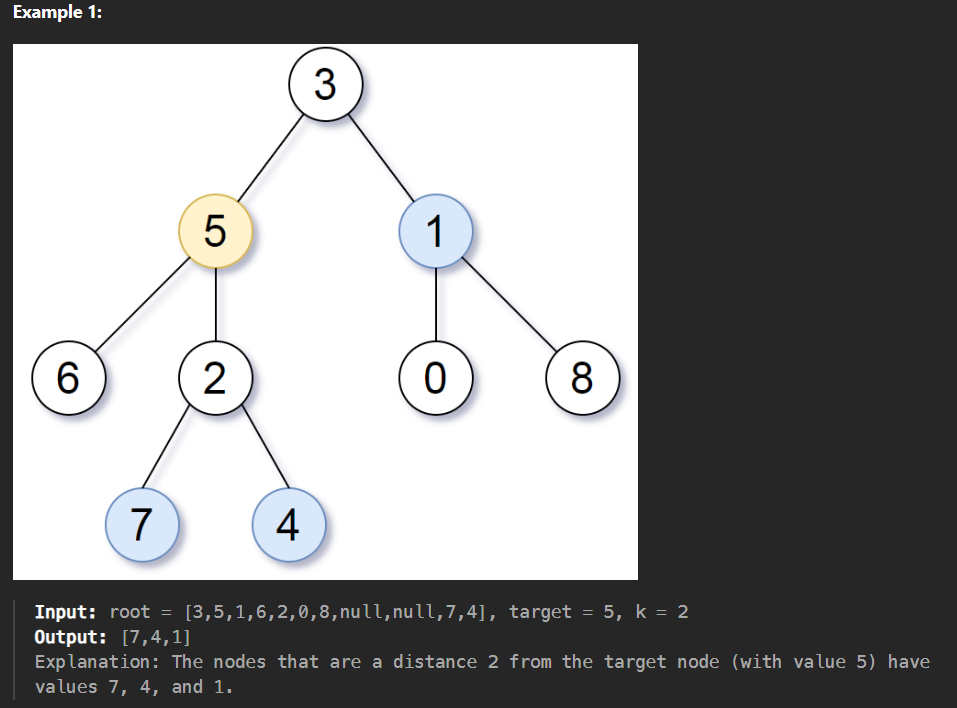

### Constraints
* The number of nodes in the tree is in the range [1, 500].
* 0 <= Node.val <= 500
* All the values Node.val are unique.
* target is the value of one of the nodes in the tree.
* 0 <= k <= 1000


## Approach 1: BFS on Graph
Because we'll need to backtrack up the tree, it's more effective to search the solution in a graph than in the original tree. So, we'll need to convert the tree into a graph. We can build an adjacency list for this.

With the adjacency list, we can simply use breath-first search to find all the nodes `k` distance away.

## Analysis
* Time Complexity: O(N)
    * traverse N nodes in the tree as we're building the adjacency matrix
    * in BFS, we only visit each node once thanks to the `seen` set so at most we visit N nodes
        * in python, `x in set()` operations are typically O(1) because sets are implemented as hash tables
* Space Complexity: O(N)
    * The main thing is storing the adjacency list
    * The adjacency list is O(N) because we need to store N nodes as keys, and each node will have at most 3 connections

In [ ]:
from collections import deque

def distanceK(self, root: TreeNode, target: TreeNode, k: int) -> List[int]:
    adjacent = {root.val: []}
    node_queue = deque([root])

    while node_queue:
        layer_len = len(node_queue)
        for index in range(layer_len):
            node = node_queue.popleft()
            if node.left != None:
                adjacent[node.val].append(node.left.val)
                adjacent[node.left.val] = [node.val]
                node_queue.append(node.left)
            if node.right != None:
                adjacent[node.val].append(node.right.val)
                adjacent[node.right.val] = [node.val]
                node_queue.append(node.right)

    node_queue = deque([target.val])
    position = 0
    seen = set()
    while position < k:
        layer_len = len(node_queue)
        for index in range(layer_len):
            node = node_queue.popleft()
            seen.add(node)
            node_queue.extend(set(adjacent[node]) - seen)
        position += 1

    return list(node_queue)